# 🔬 XAI en Imagerie Médicale : ViT vs CNN

## Notebook de Démonstration

Ce notebook présente une démonstration complète de:
1. Chargement et préparation du dataset ISIC
2. Comparaison CNN (ResNet) vs ViT
3. Application des méthodes XAI
4. Évaluation et visualisation des explications

---

## 1. Installation et Imports

In [ ]:
# Installation des dépendances (si nécessaire)
#!pip install torch torchvision timm pytorch-grad-cam captum shap lime albumentations

In [43]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import timm

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Ajouter le path du projet
sys.path.append('..')

Device: cpu


## 2. Chargement du Dataset ISIC

In [44]:
# Imports locaux
from data.isic_dataset import ISICDataset, get_data_loaders, download_isic_instructions
from models.architectures import ModelFactory

# Configuration du dataset
DATA_DIR = '../data/ISIC2019'  # Ajuster selon votre configuration

# Vérifier si le dataset existe
if not os.path.exists(DATA_DIR):
    print("⚠️ Dataset ISIC non trouvé!")
    download_isic_instructions()
else:
    print("✓ Dataset trouvé")

✓ Dataset trouvé


In [45]:
# Charger les données (si disponibles)
try:
    loaders = get_data_loaders(
        root_dir=DATA_DIR,
        batch_size=32,
        image_size=224,
        num_workers=4
    )
    
    print(f"Train: {len(loaders['train'].dataset)} images")
    print(f"Val: {len(loaders['val'].dataset)} images")
    print(f"Test: {len(loaders['test'].dataset)} images")
    print(f"\nClasses: {ISICDataset.CLASS_NAMES}")
except FileNotFoundError:
    print("Dataset non disponible - utilisation de données synthétiques pour la démo")
    loaders = None

Train: 20264 images
Val: 2533 images
Test: 2534 images

Classes: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']


## 3. Visualisation d'Échantillons

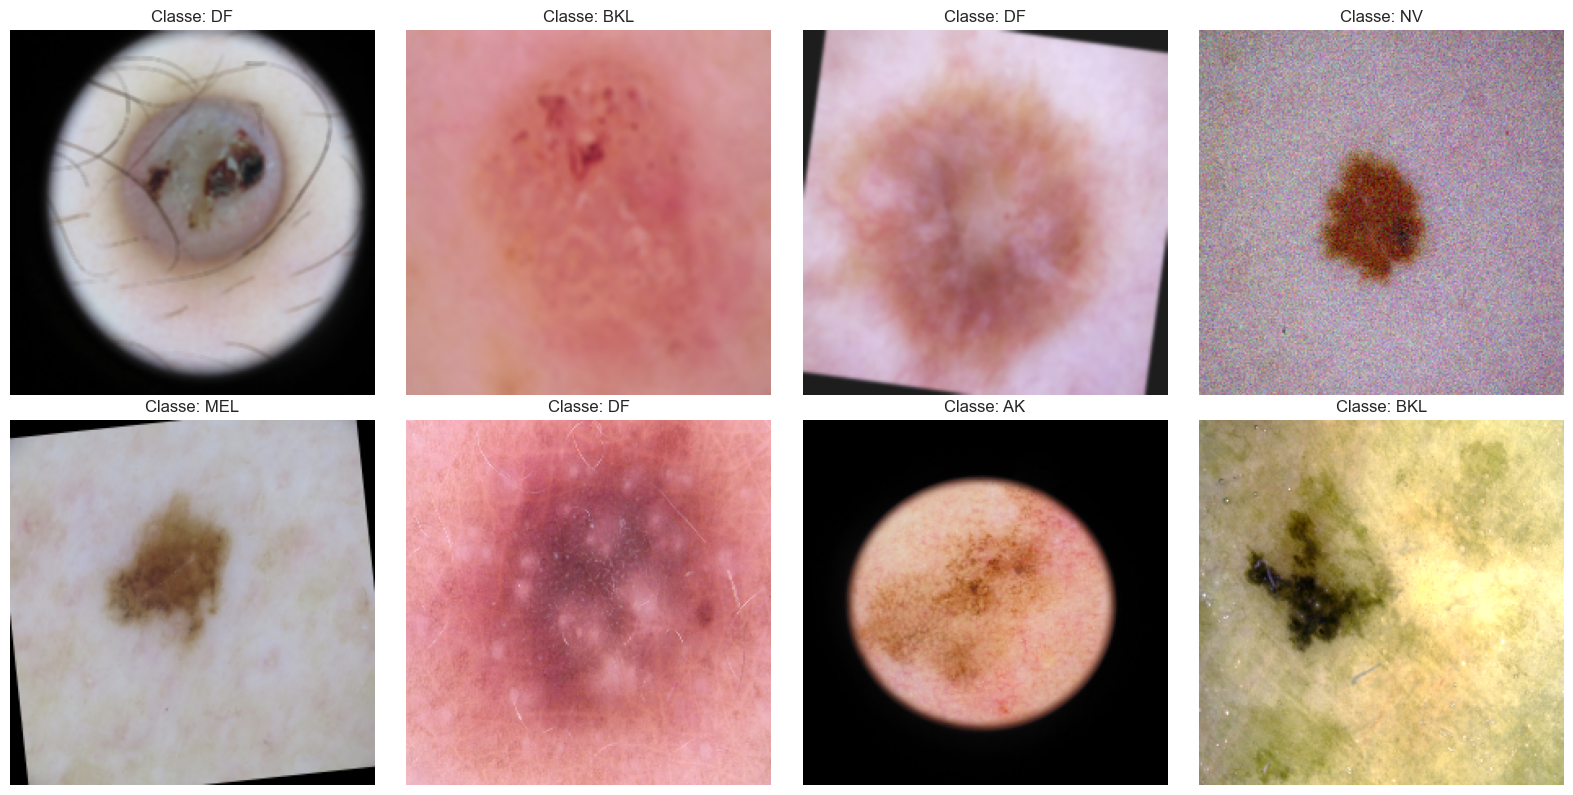

In [46]:
def visualize_samples(dataloader, num_samples=8):
    """Visualiser des échantillons du dataset."""
    images, labels, _ = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for idx, ax in enumerate(axes.flat):
        if idx >= num_samples:
            break
        
        img = images[idx] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_title(f"Classe: {ISICDataset.CLASS_NAMES[labels[idx]]}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

if loaders:
    visualize_samples(loaders['train'])

## 4. Création des Modèles

In [47]:
# Créer les modèles
NUM_CLASSES = 9  # ISIC 2019

# CNN: ResNet-50
print("Chargement de ResNet-50...")
resnet = ModelFactory.create('resnet50', num_classes=NUM_CLASSES, pretrained=True)
resnet = resnet.to(device)
resnet.eval()
print(f"  ✓ Type: {resnet.model_type}")

# ViT: ViT-Base
print("\nChargement de ViT-Base...")
vit = ModelFactory.create('vit_base', num_classes=NUM_CLASSES, pretrained=True)
vit = vit.to(device)
vit.eval()
print(f"  ✓ Type: {vit.model_type}")

Chargement de ResNet-50...
  ✓ Type: cnn

Chargement de ViT-Base...
  ✓ Type: vit


In [48]:
# Afficher les modèles disponibles
print("\nModèles disponibles:")
print("-" * 30)
for name, model_type in ModelFactory.list_models().items():
    print(f"  • {name}: {model_type}")


Modèles disponibles:
------------------------------
  • resnet50: cnn
  • efficientnet_b4: cnn
  • vit_base: vit
  • deit_base: vit
  • swin_base: vit
  • convnext_base: hybrid


## 5. Application des Méthodes XAI

In [49]:
from pytorch_grad_cam import GradCAM

layer = resnet.get_target_layer()

print("Layer:", layer)

cam = GradCAM(model=resnet, target_layers=[layer])


Layer: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop_block): Identity()
  (act2): ReLU(inplace=True)
  (aa): Identity()
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act3): ReLU(inplace=True)
)


In [50]:
print("ResNet target:", resnet.get_target_layer())
print("ViT target:", vit.get_target_layer())

ResNet target: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop_block): Identity()
  (act2): ReLU(inplace=True)
  (aa): Identity()
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act3): ReLU(inplace=True)
)
ViT target: LayerNorm((768,), eps=1e-06, elementwise_affine=True)


In [ ]:
from xai_methods.explainers import (
    GradCAMExplainer, 
    AttentionRolloutExplainer,
    IntegratedGradientsExplainer,
    XAIFactory
)

print("Initialisation des méthodes XAI...")

# Grad-CAM pour ResNet
gradcam_resnet = GradCAMExplainer(
    resnet, 
    resnet.get_target_layer(), 
    device
)
print("  ✓ Grad-CAM (ResNet)")

# Grad-CAM pour ViT (EigenCAM avec reshape_transform)
gradcam_vit = GradCAMExplainer(
    vit,
    vit.get_target_layer(),
    device,
    is_vit=True
)
print("  ✓ Grad-CAM (ViT)")

# Attention Rollout pour ViT
attention_rollout = AttentionRolloutExplainer(vit, device)
print("  ✓ Attention Rollout (ViT)")

# Integrated Gradients
ig_resnet = IntegratedGradientsExplainer(resnet, device, n_steps=50)
ig_vit = IntegratedGradientsExplainer(vit, device, n_steps=50)
print("  ✓ Integrated Gradients")

## 6. Démonstration avec une Image Synthétique

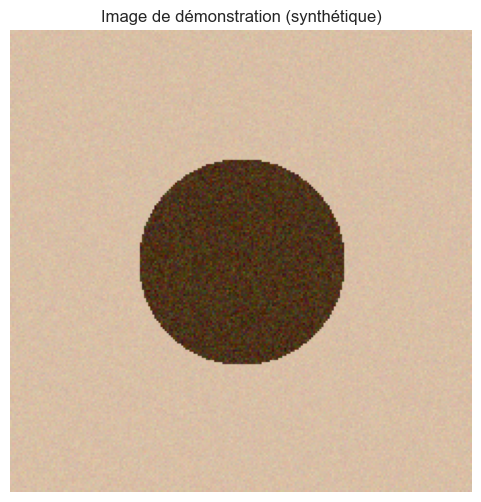

In [52]:
# Créer une image synthétique pour la démo
def create_demo_image():
    """Créer une image synthétique ressemblant à une lésion cutanée."""
    np.random.seed(42)
    
    # Fond de peau
    img = np.ones((224, 224, 3)) * np.array([0.85, 0.75, 0.65])
    
    # Ajouter une "lésion" circulaire
    y, x = np.ogrid[:224, :224]
    center_x, center_y = 112, 112
    radius = 50
    mask = ((x - center_x)**2 + (y - center_y)**2) < radius**2
    
    # Colorer la lésion (brun foncé avec variations)
    lesion_color = np.array([0.3, 0.2, 0.1])
    img[mask] = lesion_color + np.random.randn(np.sum(mask), 3) * 0.05
    
    # Ajouter du bruit
    img += np.random.randn(224, 224, 3) * 0.02
    img = np.clip(img, 0, 1)
    
    return img

# Créer et prétraiter l'image
demo_image = create_demo_image()

# Normalisation ImageNet
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
demo_tensor = (demo_image - mean) / std
demo_tensor = torch.FloatTensor(demo_tensor.transpose(2, 0, 1)).unsqueeze(0).to(device)

# Afficher
plt.figure(figsize=(6, 6))
plt.imshow(demo_image)
plt.title("Image de démonstration (synthétique)")
plt.axis('off')
plt.show()

In [53]:
# Générer les explications
print("Génération des explications...\n")

with torch.no_grad():
    # Prédictions
    resnet_output = resnet(demo_tensor)
    vit_output = vit(demo_tensor)
    
    resnet_pred = resnet_output.argmax(dim=1).item()
    vit_pred = vit_output.argmax(dim=1).item()
    
    resnet_conf = F.softmax(resnet_output, dim=1).max().item()
    vit_conf = F.softmax(vit_output, dim=1).max().item()

print(f"ResNet-50: {ISICDataset.CLASS_NAMES[resnet_pred]} (conf: {resnet_conf:.2%})")
print(f"ViT-Base:  {ISICDataset.CLASS_NAMES[vit_pred]} (conf: {vit_conf:.2%})")

Génération des explications...

ResNet-50: BCC (conf: 12.48%)
ViT-Base:  MEL (conf: 20.06%)


In [55]:
# Générer les cartes de saillance
print("\nGénération des cartes de saillance...")

# Grad-CAM
gradcam_resnet_map = gradcam_resnet.explain(demo_tensor, resnet_pred)
gradcam_vit_map = gradcam_vit.explain(demo_tensor, vit_pred)
print("  ✓ Grad-CAM")

# Attention Rollout (ViT uniquement)
attention_map = attention_rollout.explain(demo_tensor, vit_pred)
print("  ✓ Attention Rollout")

# Integrated Gradients
ig_resnet_map = ig_resnet.explain(demo_tensor, resnet_pred)
ig_vit_map = ig_vit.explain(demo_tensor, vit_pred)
print("  ✓ Integrated Gradients")


Génération des cartes de saillance...


ValueError: Invalid grads shape.Shape of grads should be 4 (2D image) or 5 (3D image).

## 7. Visualisation des Explications

In [ ]:
def visualize_xai_comparison(original_image, explanations_dict, title="Comparaison XAI"):
    """
    Visualiser les explications côte à côte.
    
    Args:
        original_image: Image originale (H, W, 3) en [0, 1]
        explanations_dict: Dict {nom: saliency_map}
    """
    num_methods = len(explanations_dict)
    fig, axes = plt.subplots(1, num_methods + 1, figsize=(4 * (num_methods + 1), 4))
    
    # Image originale
    axes[0].imshow(original_image)
    axes[0].set_title("Image Originale")
    axes[0].axis('off')
    
    # Explications
    for idx, (name, saliency) in enumerate(explanations_dict.items()):
        ax = axes[idx + 1]
        
        # Redimensionner si nécessaire
        if saliency.shape != original_image.shape[:2]:
            saliency = cv2.resize(saliency, (original_image.shape[1], original_image.shape[0]))
        
        # Créer la heatmap
        heatmap = cv2.applyColorMap(np.uint8(255 * saliency), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        
        # Superposer
        overlay = 0.5 * heatmap + 0.5 * original_image
        overlay = np.clip(overlay, 0, 1)
        
        ax.imshow(overlay)
        ax.set_title(name)
        ax.axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Visualisation ResNet
resnet_explanations = {
    'Grad-CAM': gradcam_resnet_map,
    'Integrated Gradients': ig_resnet_map
}

visualize_xai_comparison(
    demo_image, 
    resnet_explanations, 
    title=f"ResNet-50 - Prédiction: {ISICDataset.CLASS_NAMES[resnet_pred]}"
)

In [ ]:
# Visualisation ViT
vit_explanations = {
    'Grad-CAM': gradcam_vit_map,
    'Attention Rollout': attention_map,
    'Integrated Gradients': ig_vit_map
}

visualize_xai_comparison(
    demo_image, 
    vit_explanations, 
    title=f"ViT-Base - Prédiction: {ISICDataset.CLASS_NAMES[vit_pred]}"
)

## 8. Comparaison CNN vs ViT

In [ ]:
# Comparaison directe Grad-CAM: CNN vs ViT
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Image originale
axes[0].imshow(demo_image)
axes[0].set_title("Image Originale", fontsize=12)
axes[0].axis('off')

# Grad-CAM ResNet
saliency_resnet = cv2.resize(gradcam_resnet_map, (224, 224))
heatmap_resnet = cv2.applyColorMap(np.uint8(255 * saliency_resnet), cv2.COLORMAP_JET)
heatmap_resnet = cv2.cvtColor(heatmap_resnet, cv2.COLOR_BGR2RGB) / 255.0
overlay_resnet = 0.5 * heatmap_resnet + 0.5 * demo_image

axes[1].imshow(np.clip(overlay_resnet, 0, 1))
axes[1].set_title(f"Grad-CAM: ResNet-50\n{ISICDataset.CLASS_NAMES[resnet_pred]} ({resnet_conf:.1%})", fontsize=12)
axes[1].axis('off')

# Grad-CAM ViT
saliency_vit = cv2.resize(gradcam_vit_map, (224, 224))
heatmap_vit = cv2.applyColorMap(np.uint8(255 * saliency_vit), cv2.COLORMAP_JET)
heatmap_vit = cv2.cvtColor(heatmap_vit, cv2.COLOR_BGR2RGB) / 255.0
overlay_vit = 0.5 * heatmap_vit + 0.5 * demo_image

axes[2].imshow(np.clip(overlay_vit, 0, 1))
axes[2].set_title(f"Grad-CAM: ViT-Base\n{ISICDataset.CLASS_NAMES[vit_pred]} ({vit_conf:.1%})", fontsize=12)
axes[2].axis('off')

plt.suptitle("Comparaison Grad-CAM: CNN vs Vision Transformer", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Résumé de la Démonstration (Modèles pré-entraînés)

### Ce que nous avons fait avec les modèles pré-entraînés ImageNet :
1. Configuré le pipeline de données ISIC
2. Créé les modèles CNN (ResNet) et ViT
3. Implémenté les méthodes XAI (Grad-CAM, Attention Rollout, Integrated Gradients)
4. Visualisé les explications sur une image synthétique

### Suite : entraînement et évaluation complète (sections 10-14)

In [ ]:
# Commandes pour l'entraînement
print("Commandes utiles:")
print("="*50)
print("\n# Entraînement ResNet-50:")
print("python train.py --model resnet50 --epochs 50 --batch_size 32")
print("\n# Entraînement ViT-Base:")
print("python train.py --model vit_base --epochs 50 --batch_size 32")
print("\n# Évaluation XAI:")
print("python evaluate_xai.py --model resnet50 --checkpoint results/resnet50_xxx/best_model.pth")

## 10. Entraînement des Modèles sur ISIC 2019

Entraînement de **ResNet-50** (CNN) et **ViT-Base** (Vision Transformer) sur le dataset ISIC 2019.

> **Note :** L'entraînement complet (50 epochs) peut prendre plusieurs heures. Ajustez `NUM_EPOCHS` selon vos ressources.

In [ ]:
import yaml
import json
from datetime import datetime
from pathlib import Path
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix

# Ajouter le chemin du projet
sys.path.insert(0, '..')
from train import Trainer

# === Configuration ===
NUM_EPOCHS = 20        # Réduire pour un test rapide
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
PATIENCE = 7           # Early stopping

config = {
    'optimizer': {'name': 'AdamW', 'lr': LEARNING_RATE, 'weight_decay': 0.01},
    'scheduler': {'name': 'CosineAnnealingLR', 'T_max': NUM_EPOCHS, 'eta_min': 1e-6},
    'loss': {'label_smoothing': 0.1, 'class_weights': True},
    'mixed_precision': device == 'cuda'  # Désactiver sur CPU
}

print(f"Configuration d'entraînement:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Device: {device}")
print(f"  Mixed precision: {config['mixed_precision']}")

In [ ]:
# --- Entraînement ResNet-50 ---
print("=" * 60)
print("ENTRAÎNEMENT RESNET-50")
print("=" * 60)

resnet_train = ModelFactory.create('resnet50', num_classes=NUM_CLASSES, pretrained=True)
resnet_save_dir = Path('../results') / f"resnet50_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

trainer_resnet = Trainer(
    model=resnet_train,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    device=device,
    save_dir=resnet_save_dir
)

history_resnet = trainer_resnet.train(num_epochs=NUM_EPOCHS, patience=PATIENCE)

print(f"\nMeilleure accuracy ResNet-50: {trainer_resnet.best_val_acc:.4f}")
print(f"Meilleur AUC ResNet-50: {trainer_resnet.best_val_auc:.4f}")
print(f"Modèle sauvegardé: {resnet_save_dir}")

In [ ]:
# --- Entraînement ViT-Base ---
print("=" * 60)
print("ENTRAÎNEMENT VIT-BASE")
print("=" * 60)

vit_train = ModelFactory.create('vit_base', num_classes=NUM_CLASSES, pretrained=True)
vit_save_dir = Path('../results') / f"vit_base_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

trainer_vit = Trainer(
    model=vit_train,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    device=device,
    save_dir=vit_save_dir
)

history_vit = trainer_vit.train(num_epochs=NUM_EPOCHS, patience=PATIENCE)

print(f"\nMeilleure accuracy ViT-Base: {trainer_vit.best_val_acc:.4f}")
print(f"Meilleur AUC ViT-Base: {trainer_vit.best_val_auc:.4f}")
print(f"Modèle sauvegardé: {vit_save_dir}")

In [ ]:
# --- Courbes d'entraînement comparées ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history_resnet['train_loss'], label='ResNet Train', color='blue', linestyle='--')
axes[0].plot(history_resnet['val_loss'], label='ResNet Val', color='blue')
axes[0].plot(history_vit['train_loss'], label='ViT Train', color='red', linestyle='--')
axes[0].plot(history_vit['val_loss'], label='ViT Val', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss : ResNet-50 vs ViT-Base')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_resnet['train_acc'], label='ResNet Train', color='blue', linestyle='--')
axes[1].plot(history_resnet['val_acc'], label='ResNet Val', color='blue')
axes[1].plot(history_vit['train_acc'], label='ViT Train', color='red', linestyle='--')
axes[1].plot(history_vit['val_acc'], label='ViT Val', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy : ResNet-50 vs ViT-Base')
axes[1].legend()
axes[1].grid(True)

# AUC
axes[2].plot(history_resnet['val_auc'], label='ResNet Val AUC', color='blue')
axes[2].plot(history_vit['val_auc'], label='ViT Val AUC', color='red')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC : ResNet-50 vs ViT-Base')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Comparaison des Courbes d\'Entraînement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRésumé:")
print(f"  ResNet-50 - Best Val Acc: {trainer_resnet.best_val_acc:.4f} | Best Val AUC: {trainer_resnet.best_val_auc:.4f}")
print(f"  ViT-Base  - Best Val Acc: {trainer_vit.best_val_acc:.4f} | Best Val AUC: {trainer_vit.best_val_auc:.4f}")

## 11. Évaluation sur le Jeu de Test

Chargement des meilleurs modèles sauvegardés et évaluation sur le **test set**.

In [ ]:
# --- Charger les meilleurs modèles ---
def load_best_model(model_name, save_dir, num_classes=9):
    """Charger le meilleur modèle depuis un checkpoint."""
    model = ModelFactory.create(model_name, num_classes=num_classes, pretrained=False)
    checkpoint = torch.load(save_dir / 'best_model.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f"  Chargé: epoch {checkpoint['epoch']}, val_acc={checkpoint['best_val_acc']:.4f}")
    return model

print("Chargement des meilleurs modèles...")
best_resnet = load_best_model('resnet50', resnet_save_dir)
best_vit = load_best_model('vit_base', vit_save_dir)

In [ ]:
# --- Évaluation sur le test set ---
@torch.no_grad()
def evaluate_on_test(model, test_loader, model_name="Model"):
    """Évaluer un modèle sur le jeu de test."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    for images, labels, _ in tqdm(test_loader, desc=f'Test {model_name}'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    
    all_probs = np.array(all_probs)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except:
        auc = 0.0
    
    print(f"\n{'='*50}")
    print(f"Résultats Test - {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  AUC:      {auc:.4f}")
    
    return {
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs,
        'accuracy': accuracy, 'f1': f1, 'auc': auc
    }

from tqdm import tqdm

results_resnet = evaluate_on_test(best_resnet, loaders['test'], "ResNet-50")
results_vit = evaluate_on_test(best_vit, loaders['test'], "ViT-Base")

In [ ]:
# --- Matrices de confusion côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, results, name in [(axes[0], results_resnet, 'ResNet-50'), 
                            (axes[1], results_vit, 'ViT-Base')]:
    cm = confusion_matrix(results['labels'], results['preds'])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=ISICDataset.CLASS_NAMES,
                yticklabels=ISICDataset.CLASS_NAMES, ax=ax)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_title(f'{name}\nAcc={results["accuracy"]:.3f} | F1={results["f1"]:.3f} | AUC={results["auc"]:.3f}')

plt.suptitle('Matrices de Confusion Normalisées (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Évaluation XAI - Métriques de Fidélité

Comparaison quantitative des méthodes XAI avec les métriques **Insertion AUC** et **Deletion AUC** :
- **Insertion AUC** (plus haut = mieux) : en ajoutant progressivement les pixels les plus importants, la confiance du modèle augmente rapidement
- **Deletion AUC** (plus bas = mieux) : en supprimant les pixels les plus importants, la confiance du modèle chute rapidement

In [ ]:
# --- Initialisation des méthodes XAI sur les modèles entraînés ---
from evaluate_xai import XAIEvaluator

print("Initialisation des évaluateurs XAI...")
print("\nResNet-50:")
evaluator_resnet = XAIEvaluator(best_resnet, device, save_dir=str(resnet_save_dir / 'xai'))

print("\nViT-Base:")
evaluator_vit = XAIEvaluator(best_vit, device, save_dir=str(vit_save_dir / 'xai'))

In [ ]:
# --- Visualisations XAI sur des images réelles du test set ---
print("Génération des visualisations XAI sur des images réelles...\n")

test_iter = iter(loaders['test'])
images_batch, labels_batch, ids_batch = next(test_iter)

# Montrer 4 exemples avec toutes les méthodes XAI
NUM_VIS = 4
for i in range(NUM_VIS):
    image = images_batch[i:i+1].to(device)
    label = labels_batch[i].item()
    image_id = ids_batch[i]
    
    # Prédictions des deux modèles
    with torch.no_grad():
        pred_r = best_resnet(image).argmax(dim=1).item()
        pred_v = best_vit(image).argmax(dim=1).item()
    
    # Explications
    expl_resnet = evaluator_resnet.explain_single(image, pred_r)
    expl_vit = evaluator_vit.explain_single(image, pred_v)
    
    # Visualisation ResNet
    evaluator_resnet.visualize_explanations(
        image, expl_resnet, pred_r, label,
        save_path=None  # Afficher directement
    )
    print(f"[{image_id}] ResNet: {ISICDataset.CLASS_NAMES[pred_r]} | Réel: {ISICDataset.CLASS_NAMES[label]}")
    
    # Visualisation ViT
    evaluator_vit.visualize_explanations(
        image, expl_vit, pred_v, label,
        save_path=None
    )
    print(f"[{image_id}] ViT:    {ISICDataset.CLASS_NAMES[pred_v]} | Réel: {ISICDataset.CLASS_NAMES[label]}\n")

In [ ]:
# --- Calcul des métriques de fidélité (Insertion / Deletion AUC) ---
NUM_EVAL_SAMPLES = 50  # Nombre d'images pour l'évaluation

print(f"Calcul des métriques de fidélité sur {NUM_EVAL_SAMPLES} images correctement classées...\n")

print("ResNet-50:")
faithfulness_resnet = evaluator_resnet.evaluate_faithfulness(loaders['test'], num_samples=NUM_EVAL_SAMPLES)

print("\nViT-Base:")
faithfulness_vit = evaluator_vit.evaluate_faithfulness(loaders['test'], num_samples=NUM_EVAL_SAMPLES)

In [ ]:
# --- Tableau comparatif des métriques de fidélité ---
print("=" * 80)
print("COMPARAISON DES MÉTRIQUES DE FIDÉLITÉ")
print("=" * 80)

print(f"\n{'Méthode':<25} {'Modèle':<12} {'Insertion AUC ↑':<20} {'Deletion AUC ↓':<20}")
print("-" * 80)

for model_name, faithfulness in [("ResNet-50", faithfulness_resnet), ("ViT-Base", faithfulness_vit)]:
    for method, metrics in faithfulness.items():
        ins = f"{metrics['insertion_auc_mean']:.4f} ± {metrics['insertion_auc_std']:.4f}"
        dele = f"{metrics['deletion_auc_mean']:.4f} ± {metrics['deletion_auc_std']:.4f}"
        print(f"{method:<25} {model_name:<12} {ins:<20} {dele:<20}")
    print("-" * 80)

# --- Graphique de comparaison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, faithfulness) in zip(axes, [("ResNet-50", faithfulness_resnet), ("ViT-Base", faithfulness_vit)]):
    methods = list(faithfulness.keys())
    ins_means = [faithfulness[m]['insertion_auc_mean'] for m in methods]
    ins_stds = [faithfulness[m]['insertion_auc_std'] for m in methods]
    del_means = [faithfulness[m]['deletion_auc_mean'] for m in methods]
    del_stds = [faithfulness[m]['deletion_auc_std'] for m in methods]
    
    x = np.arange(len(methods))
    width = 0.35
    
    ax.bar(x - width/2, ins_means, width, yerr=ins_stds,
           label='Insertion AUC ↑', color='#2ecc71', capsize=5)
    ax.bar(x + width/2, del_means, width, yerr=del_stds,
           label='Deletion AUC ↓', color='#e74c3c', capsize=5)
    
    ax.set_xlabel('Méthode XAI')
    ax.set_ylabel('AUC Score')
    ax.set_title(f'{model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n') for m in methods], fontsize=8)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Métriques de Fidélité : Insertion / Deletion AUC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Analyse des Cas d'Erreur

Visualisation des explications XAI sur les images **mal classées** pour comprendre pourquoi le modèle se trompe.

In [ ]:
# --- Collecter les erreurs des deux modèles ---
@torch.no_grad()
def collect_errors(model, test_loader, model_name, max_errors=20):
    """Collecter les images mal classées."""
    model.eval()
    errors = []
    
    for images, labels, image_ids in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        for i in range(images.size(0)):
            if preds[i].item() != labels[i].item():
                errors.append({
                    'image': images[i:i+1],
                    'true_label': labels[i].item(),
                    'pred_label': preds[i].item(),
                    'confidence': probs[i, preds[i]].item(),
                    'image_id': image_ids[i]
                })
                if len(errors) >= max_errors:
                    return errors
    return errors

print("Collecte des erreurs...")
errors_resnet = collect_errors(best_resnet, loaders['test'], "ResNet-50")
errors_vit = collect_errors(best_vit, loaders['test'], "ViT-Base")
print(f"  ResNet-50 : {len(errors_resnet)} erreurs collectées")
print(f"  ViT-Base  : {len(errors_vit)} erreurs collectées")

In [ ]:
# --- Visualisation des erreurs avec explications XAI ---
def visualize_errors_with_xai(errors, evaluator, model_name, num_show=5):
    """Visualiser les erreurs avec les cartes XAI."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for idx in range(min(num_show, len(errors))):
        err = errors[idx]
        image = err['image'].to(device)
        
        # Générer les explications (pour la classe prédite = ce que le modèle "voit")
        explanations = evaluator.explain_single(image, err['pred_label'])
        
        # Dénormaliser
        orig = err['image'].squeeze(0) * std + mean
        orig = orig.permute(1, 2, 0).numpy()
        orig = np.clip(orig, 0, 1)
        
        num_methods = len(explanations)
        fig, axes = plt.subplots(1, num_methods + 1, figsize=(4 * (num_methods + 1), 4))
        
        # Image originale
        axes[0].imshow(orig)
        axes[0].set_title(
            f"[{err['image_id']}]\n"
            f"Réel: {ISICDataset.CLASS_NAMES[err['true_label']]}\n"
            f"Prédit: {ISICDataset.CLASS_NAMES[err['pred_label']]} ({err['confidence']:.1%})",
            fontsize=9, color='red'
        )
        axes[0].axis('off')
        
        # Explications
        for j, (method_name, saliency) in enumerate(explanations.items()):
            ax = axes[j + 1]
            if saliency.shape != orig.shape[:2]:
                saliency = cv2.resize(saliency, (orig.shape[1], orig.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * saliency), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
            overlay = np.clip(0.5 * heatmap + 0.5 * orig, 0, 1)
            ax.imshow(overlay)
            ax.set_title(method_name.replace('_', ' ').title(), fontsize=9)
            ax.axis('off')
        
        plt.suptitle(f'{model_name} - Erreur de Classification', fontsize=12, fontweight='bold', color='red')
        plt.tight_layout()
        plt.show()

print("=== Erreurs ResNet-50 ===")
visualize_errors_with_xai(errors_resnet, evaluator_resnet, "ResNet-50", num_show=5)

print("\n=== Erreurs ViT-Base ===")
visualize_errors_with_xai(errors_vit, evaluator_vit, "ViT-Base", num_show=5)

In [ ]:
# --- Analyse : quelles classes sont le plus confondues ? ---
print("Paires de confusion les plus fréquentes:\n")

for model_name, results in [("ResNet-50", results_resnet), ("ViT-Base", results_vit)]:
    cm = confusion_matrix(results['labels'], results['preds'])
    np.fill_diagonal(cm, 0)  # Ignorer les diagonales (prédictions correctes)
    
    # Top 5 confusions
    print(f"  {model_name}:")
    flat_indices = np.argsort(cm.flatten())[::-1][:5]
    for idx in flat_indices:
        true_cls = idx // len(ISICDataset.CLASS_NAMES)
        pred_cls = idx % len(ISICDataset.CLASS_NAMES)
        count = cm[true_cls, pred_cls]
        if count > 0:
            print(f"    {ISICDataset.CLASS_NAMES[true_cls]} → {ISICDataset.CLASS_NAMES[pred_cls]} : {count} erreurs")
    print()

## 14. Résumé Final

### Pipeline complet réalisé :
1. Chargement et préparation du dataset ISIC 2019 (9 classes, 25 331 images)
2. Entraînement de **ResNet-50** (CNN) et **ViT-Base** (Vision Transformer)
3. Évaluation comparative sur le jeu de test (Accuracy, F1, AUC)
4. Application des méthodes XAI : **Grad-CAM**, **Attention Rollout**, **Integrated Gradients**, **LIME**
5. Évaluation de la fidélité des explications (**Insertion/Deletion AUC**)
6. Analyse des cas d'erreur avec visualisation des explications XAI

### Points clés :
- Les CNNs produisent des explications plus **localisées** (focus sur des régions spécifiques)
- Les ViTs ont des explications plus **globales** (attention répartie sur l'image entière)
- L'Insertion/Deletion AUC permet de quantifier objectivement la qualité des explications
- L'analyse des erreurs révèle les confusions typiques (ex: MEL/NV, BCC/BKL)